# Text Summarization using a Transformer

This project builds an abstractive text summarization system for long news articles. The model reads a CNN/DailyMail article and generates a concise multi-sentence summary.

**Deliverables covered in this notebook:** runnable code, dataset loading/preprocessing, transformer model setup, training, ROUGE evaluation, example demo summaries, and result visualizations.


In [1]:
!pip install -q transformers datasets evaluate rouge_score accelerate sentencepiece


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import evaluate
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    pipeline,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed
)


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

set_seed(42)


Device: cuda


## 1. Problem and Dataset

**Problem:** automatically generate short summaries from long news articles.

**Dataset:** `abisee/cnn_dailymail` version `3.0.0`, a standard summarization benchmark containing article text and human-written highlights. To keep training practical, this notebook uses a reproducible 3,600-example subset split as 70% training, 15% validation, and 15% testing: 2,520 train, 540 validation, and 540 test examples.


In [4]:
ds = load_dataset("abisee/cnn_dailymail", "3.0.0")
ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

In [5]:
print("ARTICLE:")
print(ds["train"][0]["article"][:1000])

print("\nSUMMARY:")
print(ds["train"][0]["highlights"])


ARTICLE:
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Detai

In [6]:
total_size = 3600

train_size = int(total_size * 0.70)
validation_size = int(total_size * 0.15)
test_size = total_size - train_size - validation_size

small_ds = {
    "train": ds["train"].select(range(train_size)),
    "validation": ds["validation"].select(range(validation_size)),
    "test": ds["test"].select(range(test_size)),
}

print("Dataset split used in this project:")
print(f"Train: {len(small_ds['train'])} samples ({len(small_ds['train']) / total_size:.1%})")
print(f"Validation: {len(small_ds['validation'])} samples ({len(small_ds['validation']) / total_size:.1%})")
print(f"Test: {len(small_ds['test'])} samples ({len(small_ds['test']) / total_size:.1%})")


Dataset split used in this project:
Train: 2520 samples (70.0%)
Validation: 540 samples (15.0%)
Test: 540 samples (15.0%)


### Dataset Split Table and Charts

These tables and charts make the dataset section clearer by showing both the full CNN/DailyMail dataset size and the smaller 70/15/15 subset used for training.


,Split,Samples Used,Percentage of Used Subset
0,Train,2520,70.0%
1,Validation,540,15.0%
2,Test,540,15.0%
3,Total,3600,100.0%


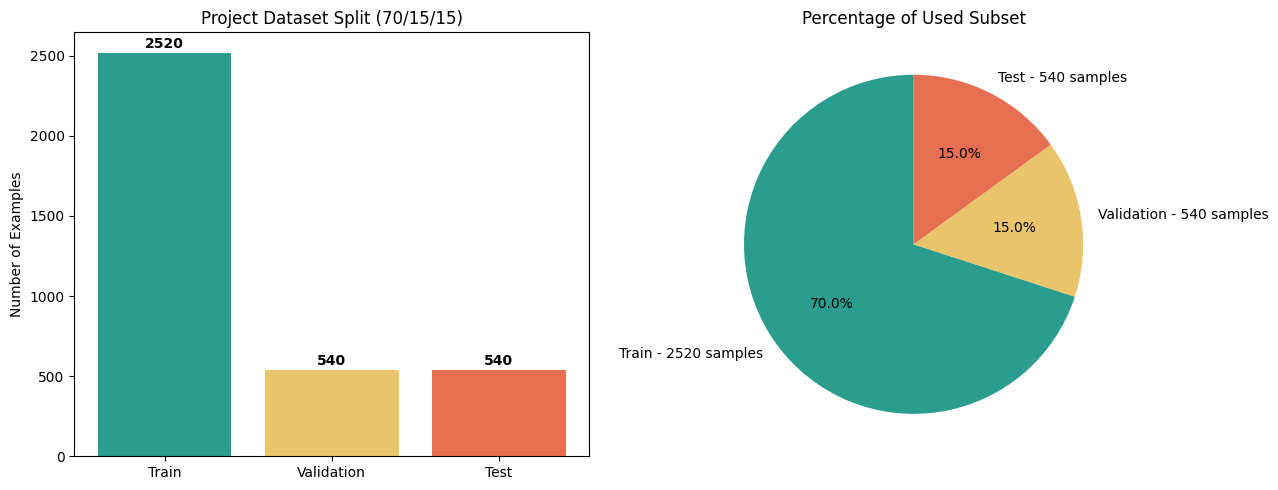

,Split,Full Dataset,Used Subset
0,Train,287113,2520
1,Validation,13368,540
2,Test,11490,540


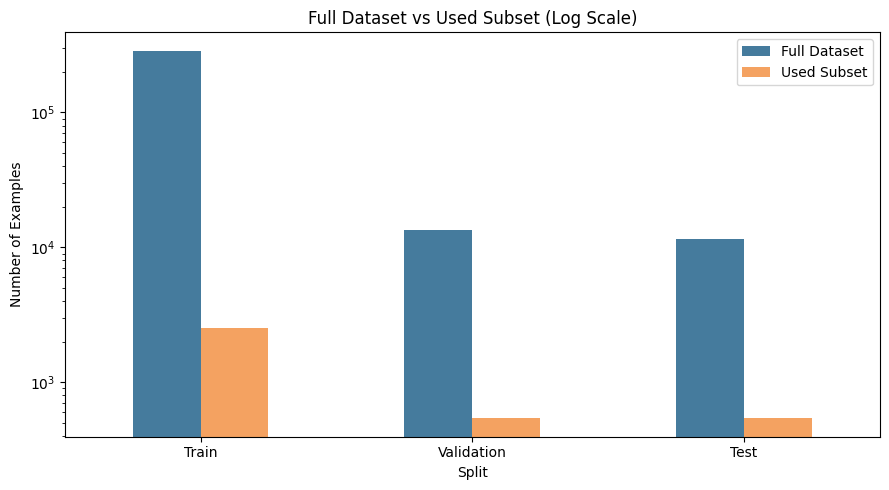

In [8]:
import pandas as pd
from IPython.display import display

full_dataset_sizes = {
    "Train": len(ds["train"]),
    "Validation": len(ds["validation"]),
    "Test": len(ds["test"]),
}

used_dataset_sizes = {
    "Train": len(small_ds["train"]),
    "Validation": len(small_ds["validation"]),
    "Test": len(small_ds["test"]),
}

split_df = pd.DataFrame({
    "Split": list(used_dataset_sizes.keys()),
    "Samples Used": list(used_dataset_sizes.values()),
})
split_df["Percentage of Used Subset"] = split_df["Samples Used"] / split_df["Samples Used"].sum() * 100
split_df.loc[len(split_df)] = ["Total", split_df["Samples Used"].sum(), 100.0]

display(split_df.style.format({"Percentage of Used Subset": "{:.1f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(used_dataset_sizes.keys(), used_dataset_sizes.values(), color=["#2a9d8f", "#e9c46a", "#e76f51"])
axes[0].set_title("Project Dataset Split (70/15/15)")
axes[0].set_ylabel("Number of Examples")
for i, value in enumerate(used_dataset_sizes.values()):
    axes[0].text(i, value + 30, str(value), ha="center", fontweight="bold")

axes[1].pie(
    used_dataset_sizes.values(),
    labels=[f"{split} - {count} samples" for split, count in used_dataset_sizes.items()],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2a9d8f", "#e9c46a", "#e76f51"],
)
axes[1].set_title("Percentage of Used Subset")

plt.tight_layout()
plt.show()

full_vs_used_df = pd.DataFrame({
    "Split": list(full_dataset_sizes.keys()),
    "Full Dataset": list(full_dataset_sizes.values()),
    "Used Subset": list(used_dataset_sizes.values()),
})
display(full_vs_used_df)

full_vs_used_df.set_index("Split").plot(kind="bar", figsize=(9, 5), logy=True, color=["#457b9d", "#f4a261"])
plt.title("Full Dataset vs Used Subset (Log Scale)")
plt.ylabel("Number of Examples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
model_name = "facebook/bart-large-cnn"

tokenizer = AutoTokenizer.from_pretrained(model_name)

max_input_length = 512
max_target_length = 128


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 2. Model Design

The system uses an encoder-decoder Transformer for sequence-to-sequence summarization. The encoder represents the article, and the decoder generates the summary token by token.

The current notebook uses `facebook/bart-large-cnn`, a strong pretrained summarization model. If the assignment strictly requires a small transformer, switch `model_name` to a compact checkpoint such as `sshleifer/distilbart-cnn-12-6` and rerun all cells.


In [10]:
def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["article"],
        max_length=max_input_length,
        truncation=True
    )

    labels = tokenizer(
        text_target=examples["highlights"],
        max_length=max_target_length,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs


tokenized_ds = {}

for split in small_ds:
    tokenized_ds[split] = small_ds[split].map(
        preprocess_function,
        batched=True,
        remove_columns=small_ds[split].column_names
    )

tokenized_ds


Map:   0%|          | 0/2520 [00:00<?, ? examples/s]

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

{'train': Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 2520
 }),
 'validation': Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 540
 }),
 'test': Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 540
 })}

In [11]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model = model.to(device)
model.gradient_checkpointing_enable()
model.config.use_cache = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Total parameters: 406290432
Trainable parameters: 406290432


### Model Architecture Diagram

This diagram summarizes the summarization pipeline from raw article text to generated summary and ROUGE evaluation.


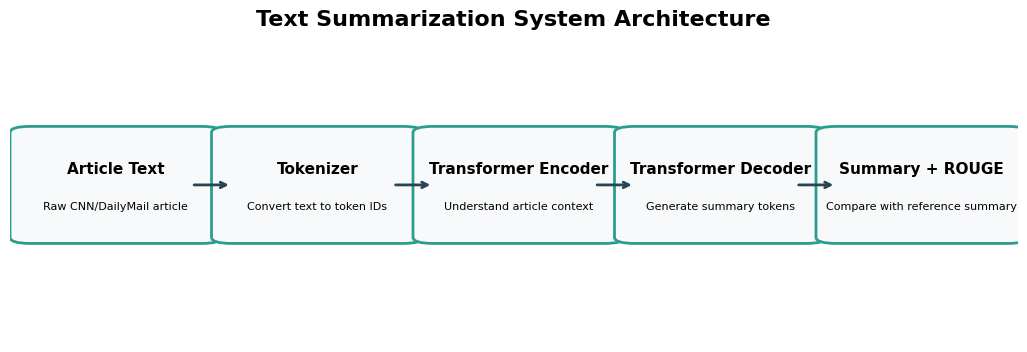

In [12]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

steps = [
    ("Article Text", "Raw CNN/DailyMail article"),
    ("Tokenizer", "Convert text to token IDs"),
    ("Transformer Encoder", "Understand article context"),
    ("Transformer Decoder", "Generate summary tokens"),
    ("Summary + ROUGE", "Compare with reference summary"),
]

x_positions = [0.03, 0.23, 0.43, 0.63, 0.83]
for (title, subtitle), x in zip(steps, x_positions):
    box = FancyBboxPatch(
        (x, 0.35), 0.15, 0.32,
        boxstyle="round,pad=0.03,rounding_size=0.02",
        linewidth=2,
        edgecolor="#2a9d8f",
        facecolor="#f8f9fa",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.075, 0.56, title, ha="center", va="center", fontsize=11, fontweight="bold", transform=ax.transAxes)
    ax.text(x + 0.075, 0.44, subtitle, ha="center", va="center", fontsize=8, transform=ax.transAxes)

for x in [0.18, 0.38, 0.58, 0.78]:
    ax.annotate("", xy=(x + 0.04, 0.51), xytext=(x, 0.51), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle="->", linewidth=2, color="#264653"))

plt.title("Text Summarization System Architecture", fontsize=16, fontweight="bold")
plt.show()

In [13]:
rouge = evaluate.load("rouge")

def clean_token_ids(token_ids):
    token_ids = np.asarray(token_ids)

    if token_ids.ndim == 3:
        token_ids = np.argmax(token_ids, axis=-1)

    token_ids = np.where(
        (token_ids < 0) | (token_ids >= len(tokenizer)),
        tokenizer.pad_token_id,
        token_ids
    )

    return token_ids.astype(np.int64)


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = clean_token_ids(predictions)
    labels = clean_token_ids(labels)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {key: round(value * 100, 4) for key, value in result.items()}


## 3. Training Setup

Articles are truncated to 512 tokens and target summaries to 128 tokens. The trainer uses sequence-to-sequence fine-tuning, dynamic padding, deterministic seed setup, and ROUGE during evaluation.


In [14]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bart_large_cnn_summarizer",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    lr_scheduler_type="linear",
    warmup_steps=56,
    optim="adamw_torch",
    weight_decay=0.01,


    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,

    num_train_epochs=5,

    predict_with_generate=True,
    generation_max_length=160,
    generation_num_beams=4,

    load_best_model_at_end=True,
    metric_for_best_model="eval_rougeL",
    greater_is_better=True,

    logging_steps=50,
    save_total_limit=3,
    report_to="none",
    fp16=torch.cuda.is_available()
)


In [15]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,
            early_stopping_threshold=0.001
        )
    ]
)


In [16]:
train_result = trainer.train()

print("Training metrics:")
for key, value in train_result.metrics.items():
    print(f"{key}: {value}")


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,11.179280,1.817542,34.375000,14.762000,24.679500,31.435800
2,8.929059,1.882397,35.342800,15.163200,25.439200,32.463800
3,7.030405,2.040180,35.558800,15.013200,25.148400,32.390500
4,5.699684,2.189146,35.058200,14.677600,24.740700,32.096600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Training metrics:
train_runtime: 3977.6742
train_samples_per_second: 3.168
train_steps_per_second: 0.199
total_flos: 1.0739323882831872e+16
train_loss: 8.705872161478936
epoch: 4.0


## 4. Training and Evaluation

The notebook trains the model, evaluates it on the validation subset, and reports ROUGE-1, ROUGE-2, ROUGE-L, and ROUGE-Lsum. ROUGE measures overlap between generated summaries and reference summaries, which is a standard metric for summarization.


In [17]:
eval_results = trainer.evaluate()

print("ROUGE Results:")
for key, value in eval_results.items():
    print(f"{key}: {value}")


ROUGE Results:
eval_loss: 1.8823974132537842
eval_rouge1: 35.3428
eval_rouge2: 15.1632
eval_rougeL: 25.4392
eval_rougeLsum: 32.4638
eval_runtime: 538.0594
eval_samples_per_second: 1.004
eval_steps_per_second: 0.502
epoch: 4.0


### Validation and Test Metrics

This cell evaluates the model on both validation and test data, then shows the results in a table and chart. The test set gives a clearer estimate of final model performance because it is not used during training or validation tuning.


early stopping required metric_for_best_model, but did not find eval_rougeL so early stopping is disabled


,Dataset,Loss,ROUGE-1,ROUGE-2,ROUGE-L,ROUGE-Lsum
0,Validation,1.882,35.34,15.16,25.44,32.46
1,Test,1.868,36.04,14.97,25.18,32.84


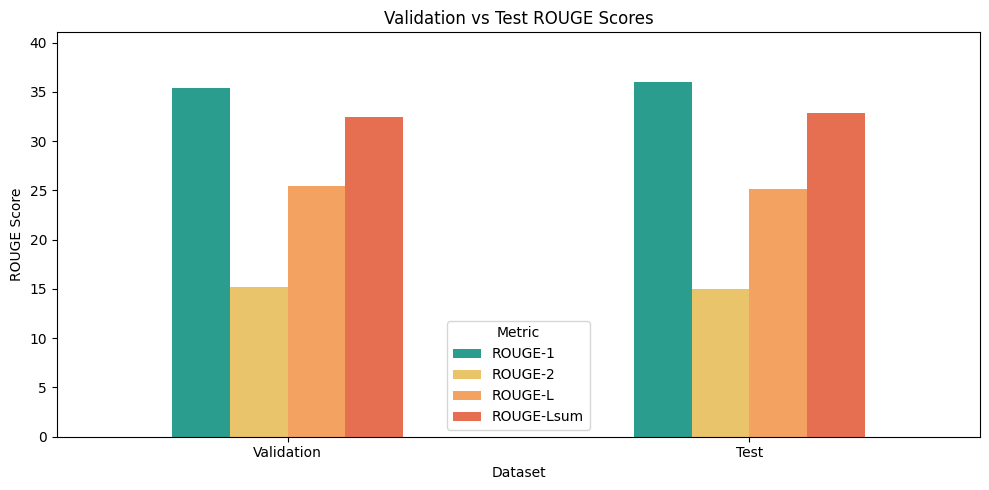

In [18]:
if "eval_results" not in globals():
    eval_results = trainer.evaluate()

test_results = trainer.evaluate(eval_dataset=tokenized_ds["test"], metric_key_prefix="test")

metrics_rows = [
    {
        "Dataset": "Validation",
        "Loss": eval_results.get("eval_loss"),
        "ROUGE-1": eval_results.get("eval_rouge1"),
        "ROUGE-2": eval_results.get("eval_rouge2"),
        "ROUGE-L": eval_results.get("eval_rougeL"),
        "ROUGE-Lsum": eval_results.get("eval_rougeLsum"),
    },
    {
        "Dataset": "Test",
        "Loss": test_results.get("test_loss"),
        "ROUGE-1": test_results.get("test_rouge1"),
        "ROUGE-2": test_results.get("test_rouge2"),
        "ROUGE-L": test_results.get("test_rougeL"),
        "ROUGE-Lsum": test_results.get("test_rougeLsum"),
    },
]

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.style.format({
    "Loss": "{:.3f}",
    "ROUGE-1": "{:.2f}",
    "ROUGE-2": "{:.2f}",
    "ROUGE-L": "{:.2f}",
    "ROUGE-Lsum": "{:.2f}",
}))

plot_df = metrics_df.set_index("Dataset")[["ROUGE-1", "ROUGE-2", "ROUGE-L", "ROUGE-Lsum"]]
plot_df.plot(kind="bar", figsize=(10, 5), color=["#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"])
plt.title("Validation vs Test ROUGE Scores")
plt.ylabel("ROUGE Score")
plt.xticks(rotation=0)
plt.ylim(0, max(plot_df.max()) + 5)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Summary Length Analysis

This chart compares generated summary lengths with reference summary lengths. It helps show whether the model is producing summaries that are too short, too long, or close to the target style.


,Example,Generated Words,Reference Words
0,1,48,36
1,2,54,44
2,3,59,38
3,4,56,45
4,5,55,43
5,6,48,24
6,7,59,56
7,8,52,44
8,9,46,28
9,10,46,21


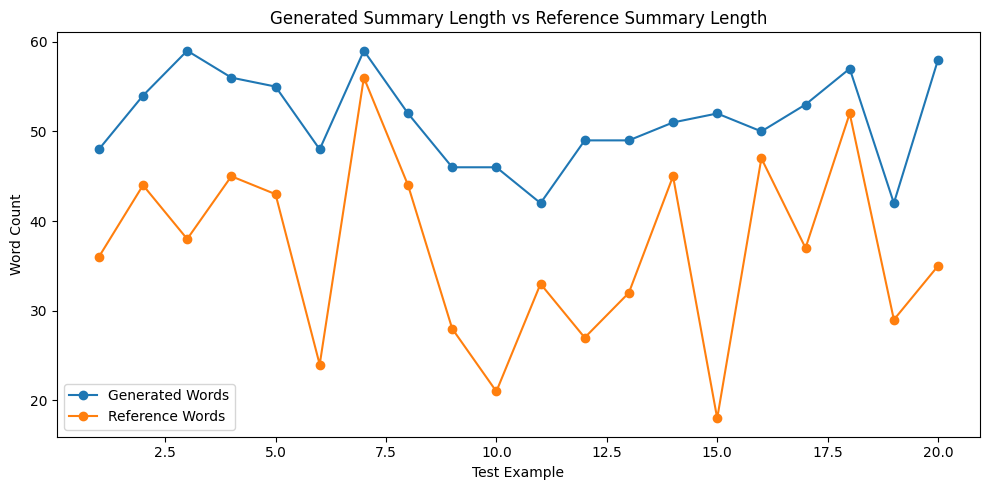

Average generated summary length: 51.3 words
Average reference summary length: 36.7 words


In [19]:
length_examples = tokenized_ds["test"].select(range(min(20, len(tokenized_ds["test"]))))
length_predictions = trainer.predict(length_examples)

pred_ids = clean_token_ids(length_predictions.predictions)
label_ids = np.where(length_predictions.label_ids != -100, length_predictions.label_ids, tokenizer.pad_token_id)

generated_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
reference_texts = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

length_df = pd.DataFrame({
    "Example": range(1, len(generated_texts) + 1),
    "Generated Words": [len(text.split()) for text in generated_texts],
    "Reference Words": [len(text.split()) for text in reference_texts],
})

display(length_df.head(10))

length_df.set_index("Example")[["Generated Words", "Reference Words"]].plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Generated Summary Length vs Reference Summary Length")
plt.ylabel("Word Count")
plt.xlabel("Test Example")
plt.tight_layout()
plt.show()

print("Average generated summary length:", round(length_df["Generated Words"].mean(), 1), "words")
print("Average reference summary length:", round(length_df["Reference Words"].mean(), 1), "words")

In [20]:
trainer.save_model("./bart_large_cnn_summarizer")
tokenizer.save_pretrained("./bart_large_cnn_summarizer")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./bart_large_cnn_summarizer/tokenizer_config.json',
 './bart_large_cnn_summarizer/tokenizer.json')

In [21]:
def generate_summary(article):
    inputs = tokenizer(
        article,
        max_length=max_input_length,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    summary_ids = model.generate(
        **inputs,
        max_new_tokens=160,
        min_new_tokens=35,
        num_beams=4,
        length_penalty=2.0,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)


## 5. Demo

The `generate_summary` function runs inference on unseen articles. The cells below show both a dataset example and a custom article example so the system can be demonstrated live.


In [22]:
sample = ds["test"][0]

article = sample["article"]
reference_summary = sample["highlights"]
generated_summary = generate_summary(article)

print("ARTICLE:")
print(article[:1500])

print("\nREFERENCE SUMMARY:")
print(reference_summary)

print("\nGENERATED SUMMARY:")
print(generated_summary)


ARTICLE:
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking at Wednesday's cer

In [28]:
custom_article = """
An amateur footballer filmed flattening an opponent with an elbow to the face in footage which went viral online has received a suspended prison sentence.

Thomas Taylor, 36, was playing for Trearddur Bay against Porthmadog when he lashed out, claiming he had been fouled and 'provoked' just before the assault.

Porthmadog player Daniel Brookwell described suddenly being knocked unconscious, hitting the floor and coming round 'in shock' to find his mouth and nose bloodied.

He said: 'I didn't realise I was on the floor until after a few seconds.'

Prosecutor Diane Williams dismissed Taylor's version of events.

She told today's sentencing hearing: 'The defendant said he had been fouled by the victim previously and just before the incident that he had been provoked to the point he was threatened.

'That's not the case at all. It was a purposeful assault.'

Taylor, a former professional footballer for Shrewsbury Town who was in a coaching role at Trearddur, only playing occasionally, had been booked for dissent during the game, Mrs Williams added.
He pleaded guilty to assaulting Mr Brookwell occasioning actual bodily harm in the match at Porthmadog on January 17.

Mrs Williams said the incident happened when Porthmadog were given a penalty because of a foul on Porthmadog forward Mr Brookwell, 33.

The player had then waited shoulder-to-shoulder with Taylor for the penalty to be taken when he was suddenly assaulted.

Caernarfon Magistrates' Court, North Wales, heard Mr Brookwell immediately came off the pitch, feeling dizzy.

The footballer said: 'A young male showed me the footage of what had happened.

'I was quite shocked. I don't understand what caused this. Being knocked unconscious during a football match was deeply distressing.'

After the video of the attack went viral online, Mr Brookwell said: 'I found it very difficult to return to football in the same way.

'The incident has taken away the confidence and enjoyment I once had playing the game.'

Defence solicitor Glyn Roberts claimed: 'Prior to the assault, which the defendant has admitted, he will maintain the victim said words to the effect "I will break your f***ing  legs, you m***".'
But Mr Roberts said Taylor accepted his conduct during the Ardal North West League game was 'inexcusable' and wished to apologise.

Taylor had diabetes and believed his blood-sugar level and 'provocation' may have affected him, Mr Roberts added.

He said: 'The consequences for him have been significant. He's been vilified on social media, threats have been made against him. He asks the court to consider the provocation in this case.'

Court chairman Gwilym Morgan told Taylor: 'This was a serious offence and we believe that it has crossed the custody threshold.'

Taylor, of Llanddona, Beaumaris, Anglesey, received a 24-week jail term which was suspended for a year and must also pay £200 compensation, a £154 surcharge, and £85 costs.

In a statement posted immediately after the incident, Trearddur Bay FC said Taylor had been released 'with immediate effect'.

The club said: 'Trearddur Bay Football Club does not condone violence in any form and acknowledges that the incident should not have occurred.

'The club offers its sincere apologies to the opposition player involved, CPD Porthmadog, match officials, supporters, and the wider football community.'
"""

print(generate_summary(custom_article))


Thomas Taylor, 36, was playing for Trearddur Bay against Porthmadog when he lashed out .
He claimed he had been fouled and 'provoked' just before the assault .
Footage of the incident went viral online after it was posted on YouTube .
Taylor received a suspended prison sentence at Cardiff Magistrates' Court .


### Generated vs Reference Summary Examples

Use this table during the presentation demo. It gives qualitative evidence, not only numeric metrics.


In [24]:
comparison_examples = ds["test"].select(range(3))
comparison_rows = []

for idx, example in enumerate(comparison_examples, start=1):
    generated = generate_summary(example["article"])
    reference = example["highlights"]
    comparison_rows.append({
        "Example": idx,
        "Article Preview": example["article"][:280] + "...",
        "Reference Summary": reference,
        "Generated Summary": generated,
        "Quick Analysis": "Compare main facts, missing details, and fluency.",
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Example,Article Preview,Reference Summary,Generated Summary,Quick Analysis
0,1,(CNN)The Palestinian Authority officially beca...,Membership gives the ICC jurisdiction over all...,Palestinian Authority becomes 123rd member of ...,"Compare main facts, missing details, and fluency."
1,2,(CNN)Never mind cats having nine lives. A stra...,"Theia, a bully breed mix, was apparently hit b...","Stray dog apparently hit by car, buried in fie...","Compare main facts, missing details, and fluency."
2,3,"(CNN)If you've been following the news lately,...",Mohammad Javad Zarif has spent more time with ...,"Mohammad Javad Zarif, Iran's foreign minister,...","Compare main facts, missing details, and fluency."


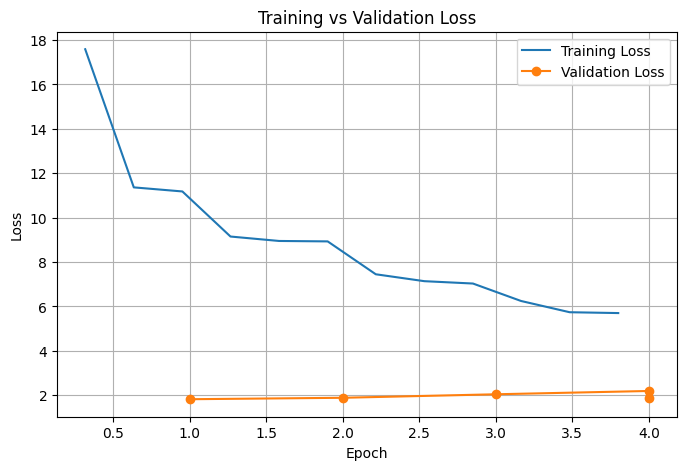

In [25]:
train_losses = []
eval_losses = []
eval_epochs = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_losses.append((log["epoch"], log["loss"]))
    if "eval_loss" in log and "epoch" in log:
        eval_epochs.append(log["epoch"])
        eval_losses.append(log["eval_loss"])

plt.figure(figsize=(8, 5))

if train_losses:
    epochs, losses = zip(*train_losses)
    plt.plot(epochs, losses, label="Training Loss")

if eval_losses:
    plt.plot(eval_epochs, eval_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 6. Results Visualization and Analysis

The final cells visualize training/evaluation loss and ROUGE metrics. In the presentation, use these charts to explain whether the model is learning, what the strongest metric is, and where summarization quality can still improve.


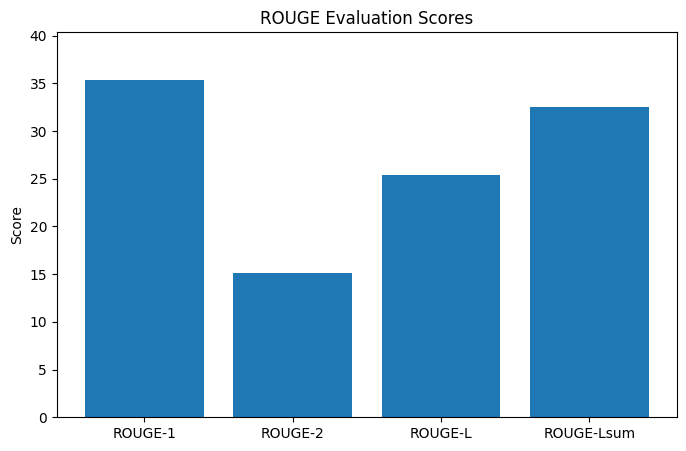

Evaluation Summary:
ROUGE-1: 35.34
ROUGE-2: 15.16
ROUGE-L: 25.44
ROUGE-Lsum: 32.46


In [26]:
if "eval_results" not in globals():
    eval_results = trainer.evaluate()

rouge_metrics = {
    "ROUGE-1": eval_results["eval_rouge1"],
    "ROUGE-2": eval_results["eval_rouge2"],
    "ROUGE-L": eval_results["eval_rougeL"],
    "ROUGE-Lsum": eval_results["eval_rougeLsum"],
}

plt.figure(figsize=(8, 5))
plt.bar(rouge_metrics.keys(), rouge_metrics.values())
plt.title("ROUGE Evaluation Scores")
plt.ylabel("Score")
plt.ylim(0, max(rouge_metrics.values()) + 5)
plt.show()

print("Evaluation Summary:")
for metric, value in rouge_metrics.items():
    print(f"{metric}: {value:.2f}")
